Load Dataset from DeepLoc


In [83]:
import pandas as pd

df = pd.read_csv("https://services.healthtech.dtu.dk/services/DeepLoc-2.0/data/Swissprot_Train_Validation_dataset.csv")

In [84]:
df.head()

,Unnamed: 0,ACC,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,0,Q28165,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
1,1,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
2,2,Q0GA42,Metazoa,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAALGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...
3,3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...


Extract Cytoplasm Presence Data

In [85]:
import numpy as np

y_data = df["Cytoplasm"].to_list()
y = 5
print(f"First {y} Entries: {y_data[:y]}")

First 5 Entries: [1.0, 1.0, 0.0, 1.0, 1.0]


Extract Protein Sequences

In [86]:
x_data = df["Sequence"].to_list()
x = 4
print(f"{x}th Entries: {x_data[x]}")

4th Entries: MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPLVILNISDHWIRMRSQEGRPVQVIGALIGKQEGRNIEVMNSFELLSHTVEEKIIIDKEYYYTKEEQFKQVFKELEFLGWYTTGGPPDPSDIHVHKQVCEIIESPLFLKLNPMTKHTDLPVSVFESVIDIINGEATMLFAELTYTLATEEAERIGVDHVARMTATGSGENSTVAEHLIAQHSAIKMLHSRVKLILEYVKASEAGEVPFNHEILREAYALCHCLPVLSTDKFKTDFYDQCNDVGLMAYLGTITKTCNTMNQFVNKFNVLYDRQGIGRRMRGLFF


Extract Features: Amino acid normalized frequency count and sequence length

In [87]:
amino_acids = np.array(["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I","L", "K", "M", "F", "P","S", "T", "W","Y","V"])

features = []
for seq in x_data: 
    if seq == " ":
        continue
    seq_length = len(seq)
    feature_vector = [seq_length]
    for amino in amino_acids:
        feature_vector.append(seq.count(amino)/seq_length)
    features.append(feature_vector)


print(f"First Entry: {features[:2]}")

First Entry: [[306, 0.11437908496732026, 0.0915032679738562, 0.03594771241830065, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09477124183006536, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098], [306, 0.11437908496732026, 0.0915032679738562, 0.032679738562091505, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09803921568627451, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098]]


In [88]:
nsamples =  len(x_data)
indices = np.arange(nsamples)
np.random.shuffle(indices)

train_split = int(nsamples*0.7)
test_split = int(nsamples*0.2) + train_split
train_idx, test_idx, validation_idx = indices[:train_split], indices[train_split:test_split], indices[test_split:]

print(f"train, test: {train_idx}")

train, test: [ 6292 14462 13634 ...  4113 13043   777]


Data splitting for Testing (70%), Training (20%), and Validation (10%)

In [89]:

X = np.array(features)
y = np.array(y_data)

X_train, y_train = X[train_idx], y[train_idx]

X_test, y_test = X[test_idx], y[test_idx]
    
X_valid, y_valid = X[validation_idx], y[validation_idx]


print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)
print(f"Y train_shape: {y_train.shape}")

(28303, 21)
(19812, 21)
(5660, 21)
(2831, 21)
Y train_shape: (19812,)


Standardization using Z-score

In [90]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1

X_train = (X_train - mean)/std
print(X_train)
X_test = (X_test - mean)/std

X_valid = (X_valid - mean)/std


[[-6.90030535e-01 -4.38271206e-01  9.00708480e-01 ...  1.06493652e+00
  -5.65931646e-01 -1.04041001e+00]
 [-4.92239505e-01  3.35537923e+00 -6.15966019e-01 ... -9.70511812e-01
  -3.85230323e-01 -1.31335292e+00]
 [-8.80357752e-01 -1.69294773e-02 -8.83346745e-01 ... -3.37571333e-02
  -4.24732473e-01 -2.12462321e-01]
 ...
 [-4.13869474e-01 -1.51433521e+00 -1.75233457e-01 ... -2.23173546e-03
   4.64065895e-01 -1.71988408e+00]
 [-1.43306273e-01 -1.38179173e-01 -4.87845625e-01 ... -4.10882163e-01
   1.17916978e+00  2.33137086e-01]
 [-2.38469882e-01  1.02762760e+00  5.99724552e-02 ...  7.60682892e-01
   7.29946132e-02 -3.35997373e-01]]


In [ ]:
import importlib
import protein_classifier

importlib.reload(protein_classifier)
from protein_classifier import ProteinClassifier

model = ProteinClassifier(x_train=X_train, y_train=y_train, x_test=X_test, y_test=y_test, x_valid=X_valid, y_valid=y_valid)

losses = model.train_cross_entropy()


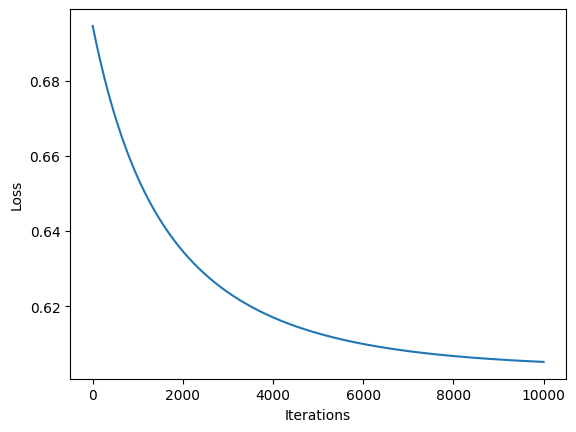

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [ ]:
y_pred = model.predict(X_test)
correct = (y_pred == y_test)
accuracy = np.mean(correct)

print(f"Accuracy: {accuracy}")

Accuracy: 0.6466431095406361


Model Evaluation

In [ ]:
print("train positive rate:", np.mean(y_train))
print("valid positive rate:", np.mean(y_valid))
print("test positive rate:", np.mean(y_test))

print("unique predictions:", np.unique(y_pred))
print("unique true labels:", np.unique(y_test))

baseline_acc = np.mean(y_test == 0)
print("always predict 0 accuracy:", baseline_acc)

y_prob = model.predict(X_test)
print(np.min(y_prob), np.max(y_prob), np.mean(y_prob))


train positive rate: 0.35074702200686453
valid positive rate: 0.33733663016601906
test positive rate: 0.3473498233215548
unique predictions: [False  True]
unique true labels: [0. 1.]
always predict 0 accuracy: 0.6526501766784453
False True 0.14416961130742048


Evaluation Metrics

In [ ]:
y_true = y_test  

TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == 0) & (y_true == 0))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

accuracy = (TP + TN) / len(y_true)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)


TP: 391 TN: 3269 FP: 425 FN: 1575
Accuracy: 0.6466431095406361
Recall: 0.19888097660223805
Precision: 0.4791666666666667
